In [3]:
import os
import glob
import pickle
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt
from coffea import util
from coffea import processor
from coffea.lookup_tools.dense_lookup import dense_lookup

hep.style.use(hep.style.CMS)
plt.rcParams.update(
{
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 20,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "lines.markersize": 30,
    "legend.fontsize": 10,
    "xtick.minor.width": 1,
    "xtick.minor.size": 4,
    "xtick.major.width": 1,
    "xtick.major.size": 6,
    "ytick.minor.width": 1,
    "ytick.minor.size": 4,
    "ytick.major.width": 1,
    "ytick.major.size": 6,
}
)

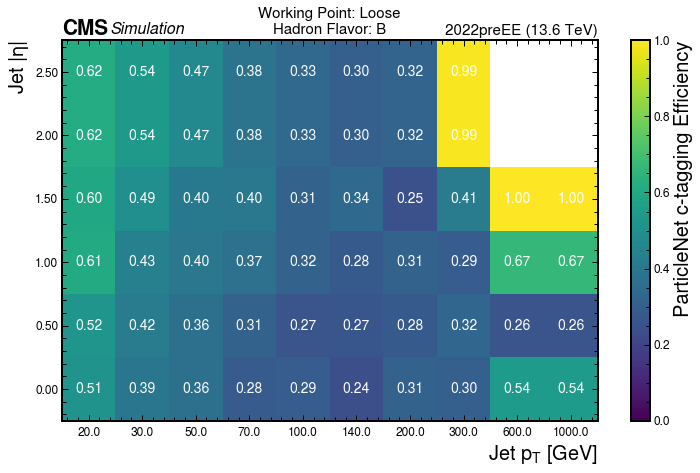

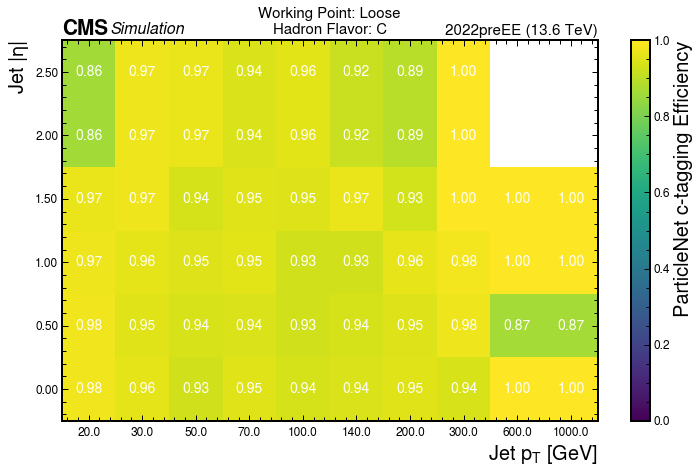

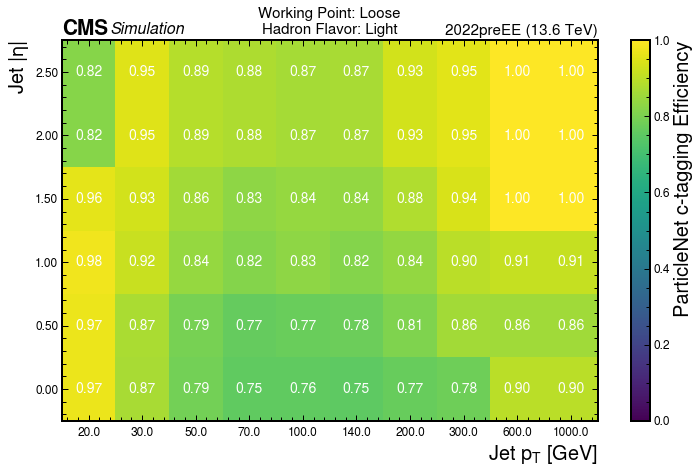

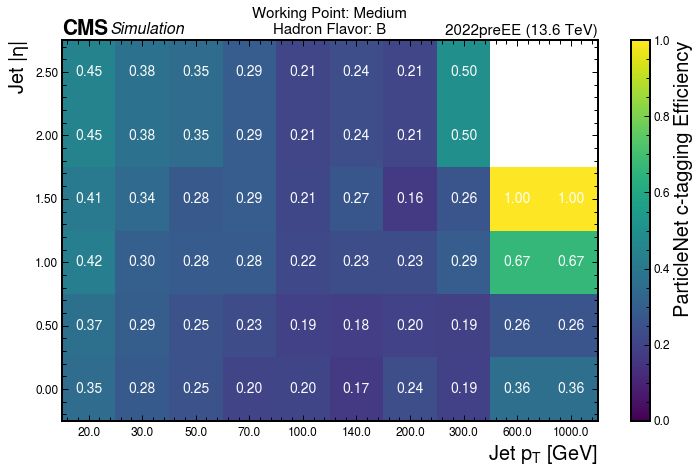

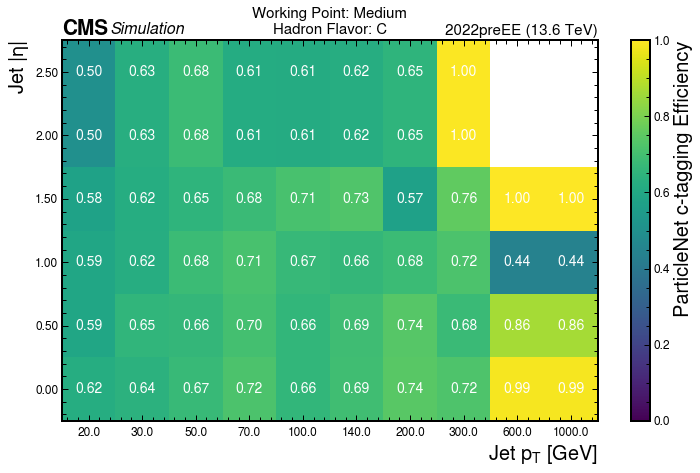

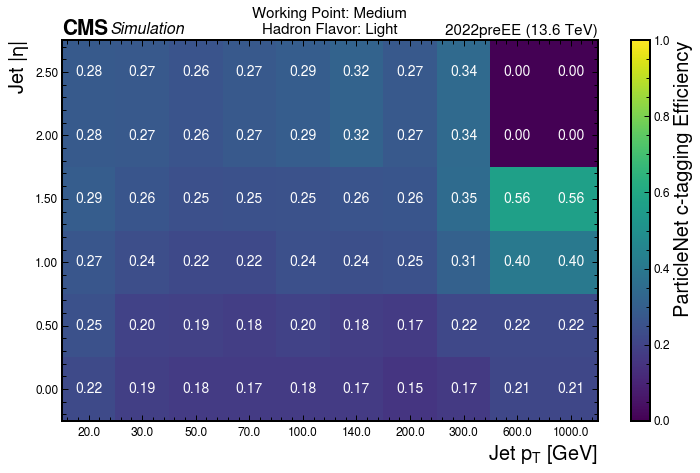

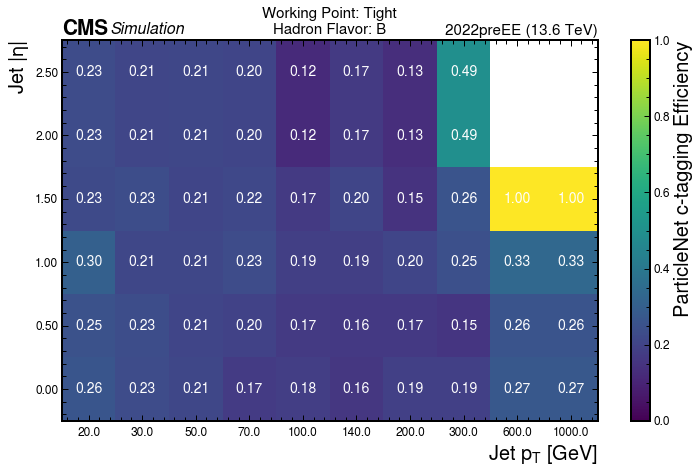

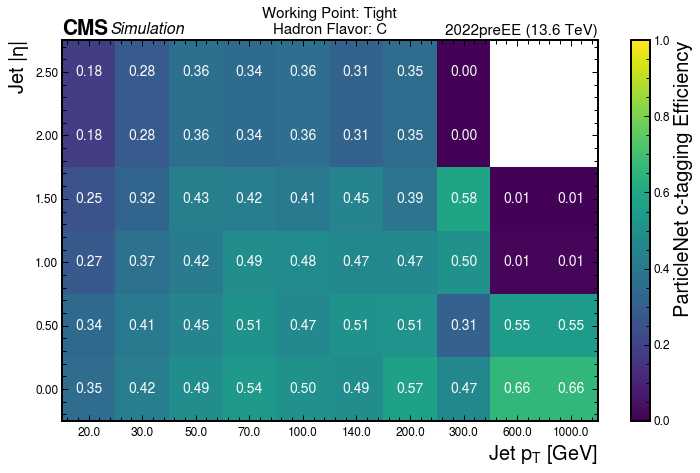

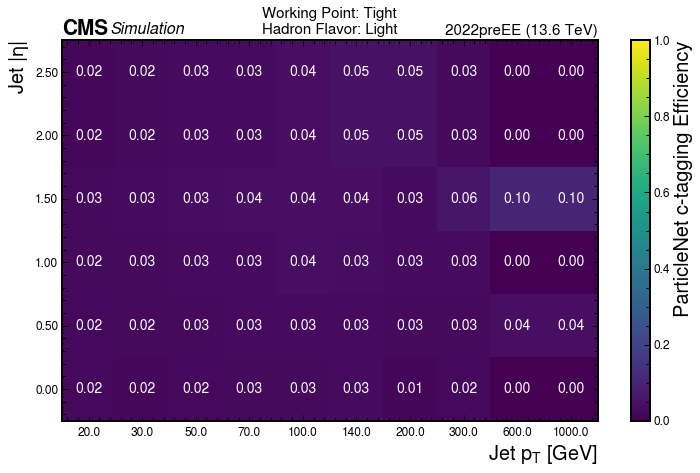

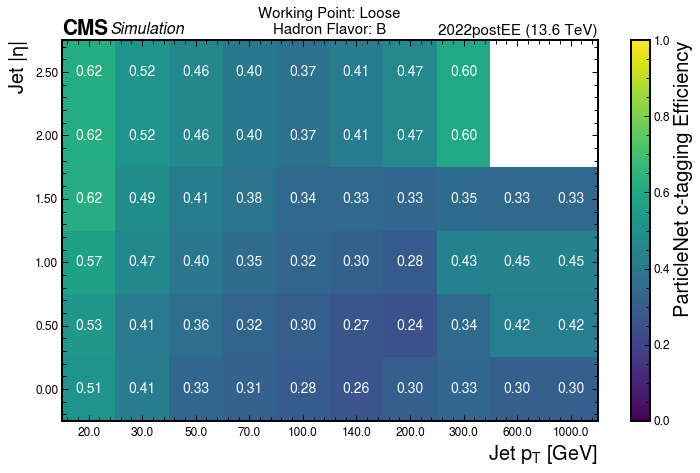

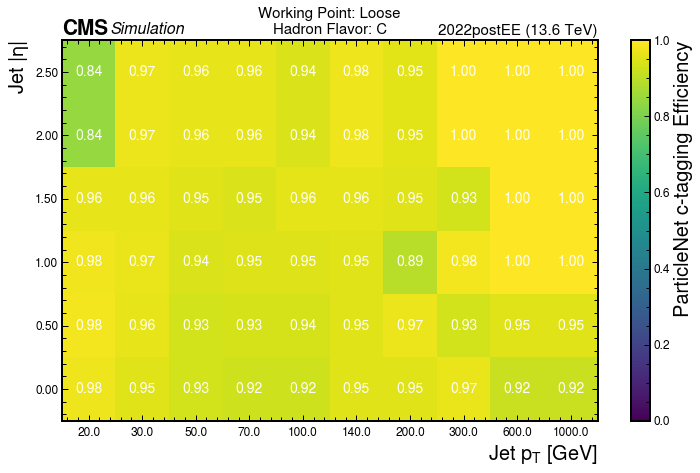

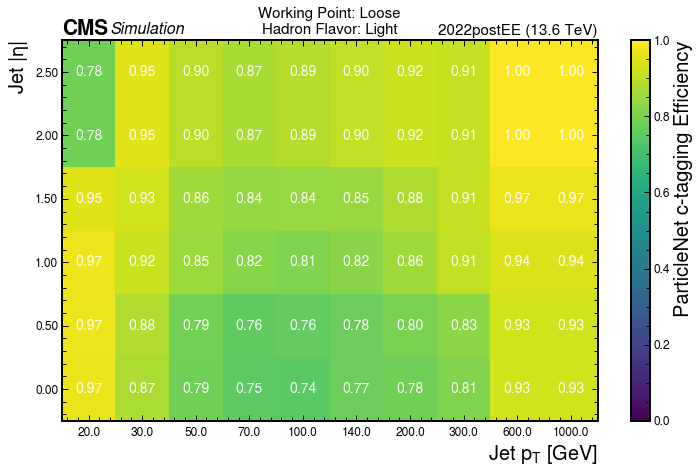

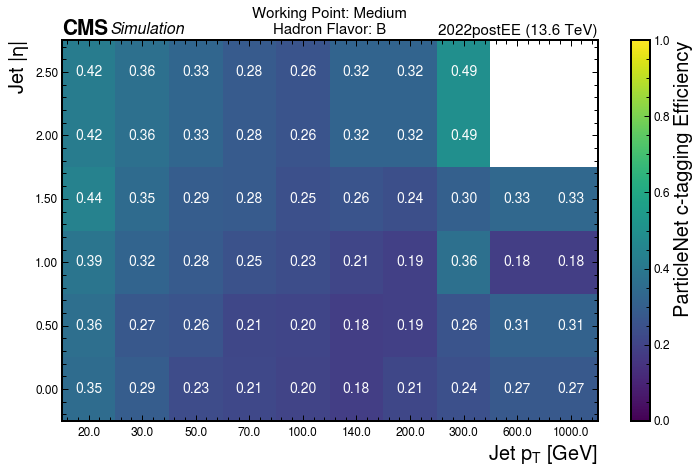

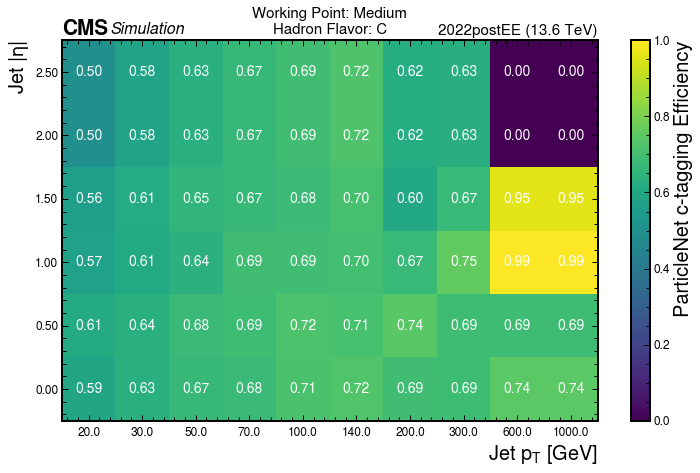

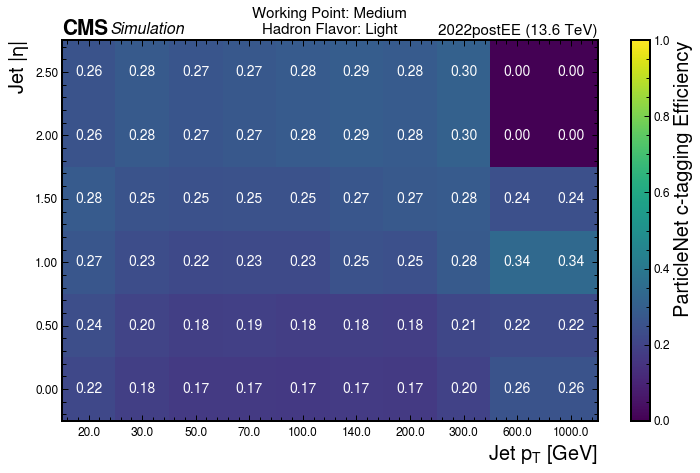

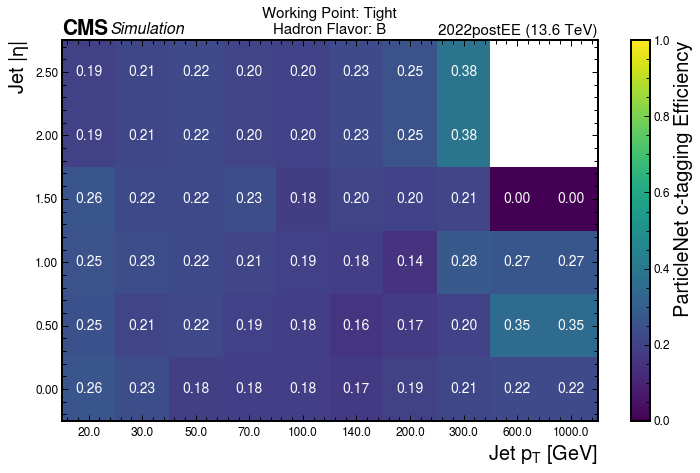

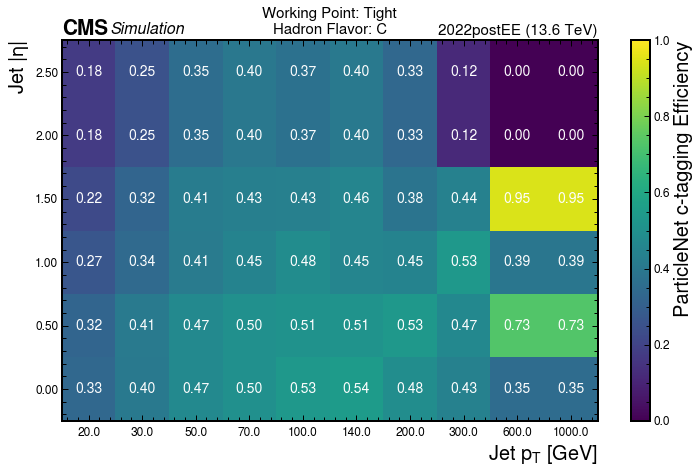

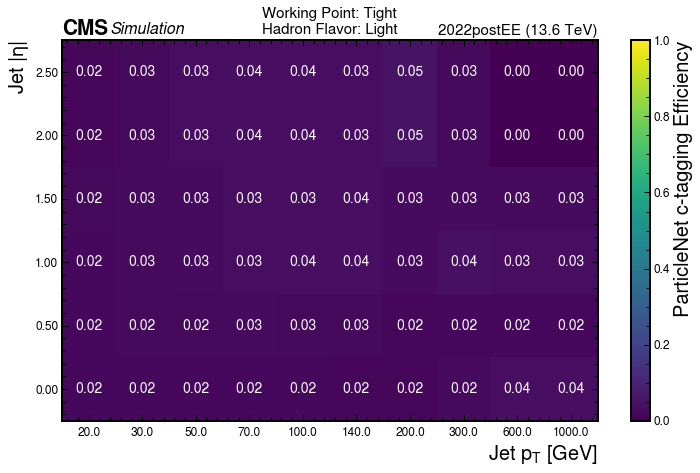

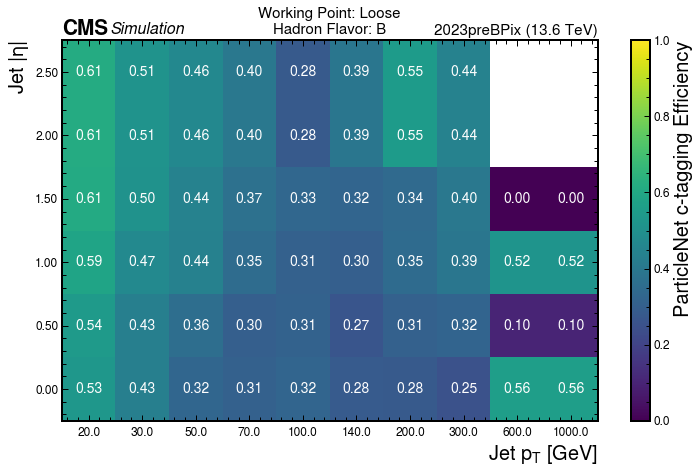

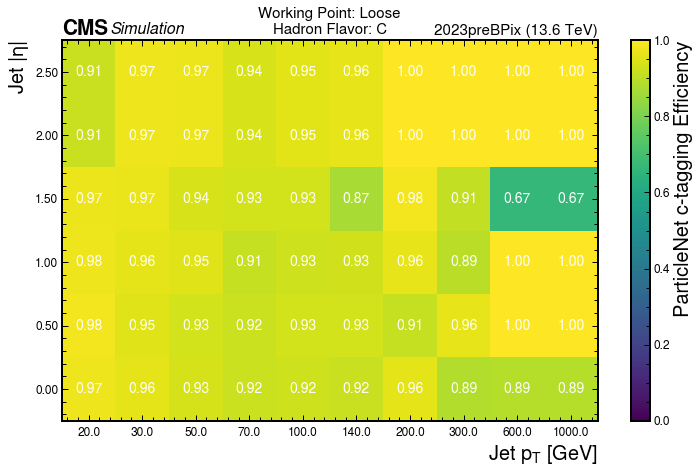

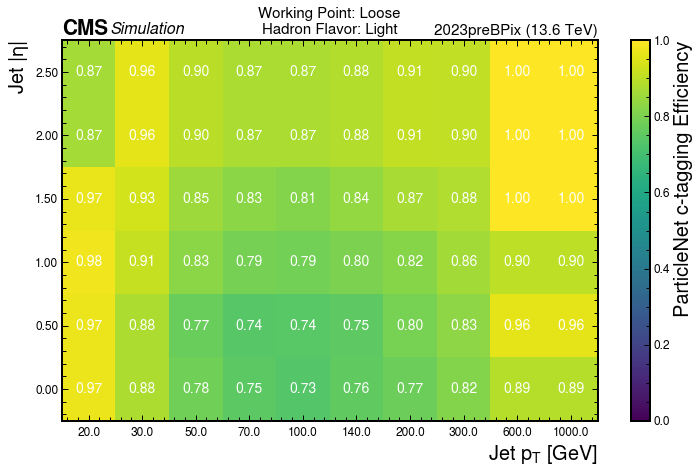

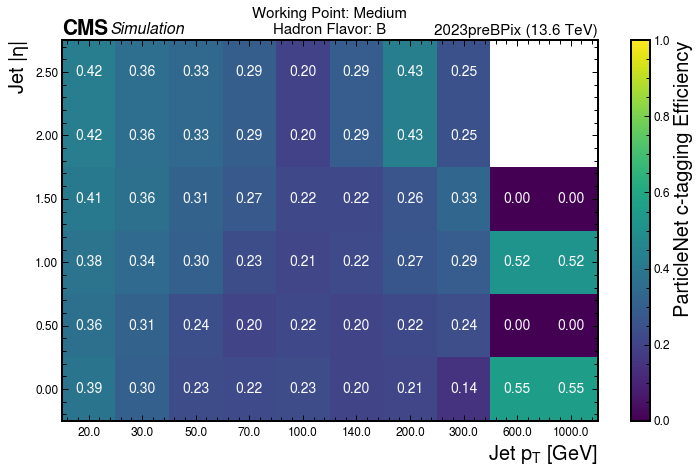

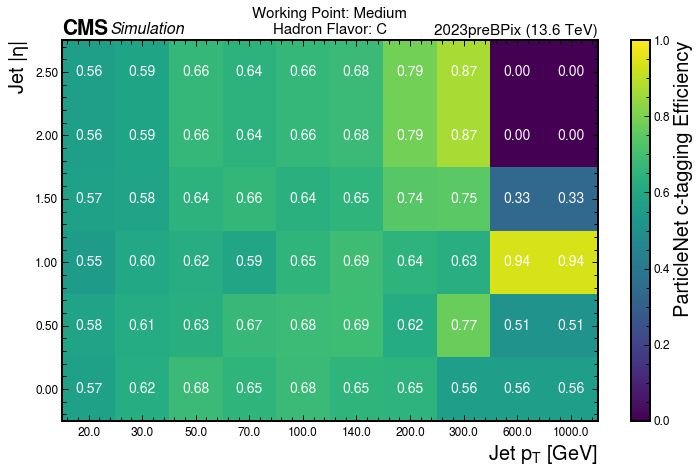

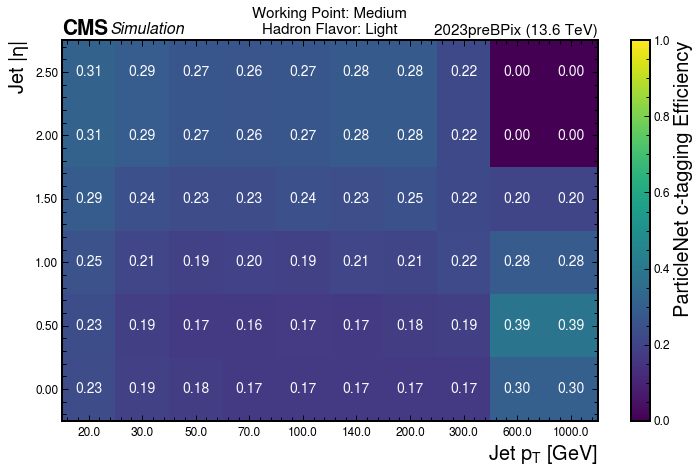

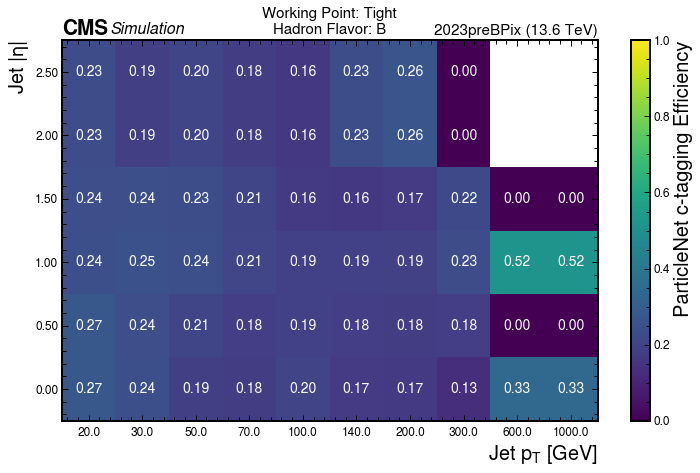

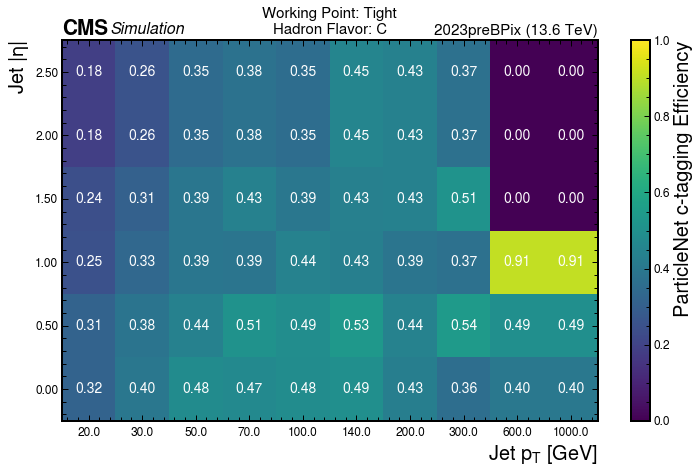

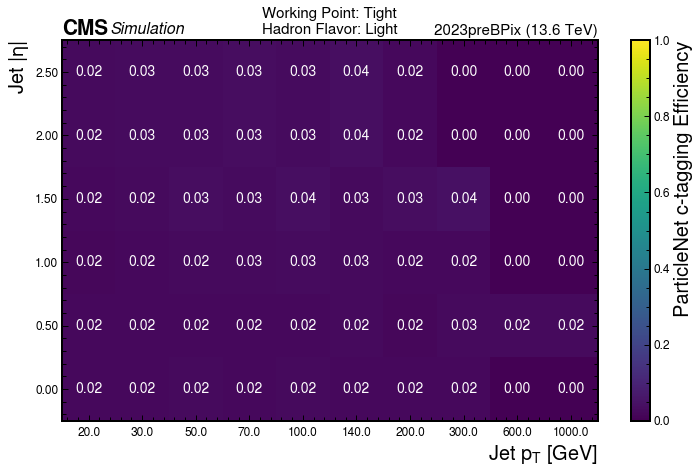

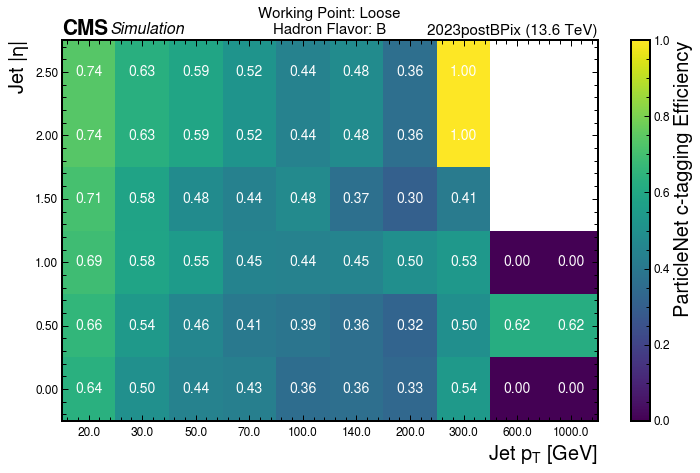

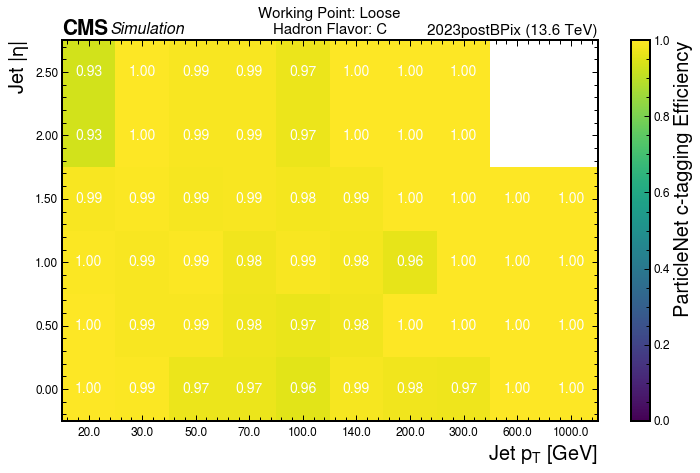

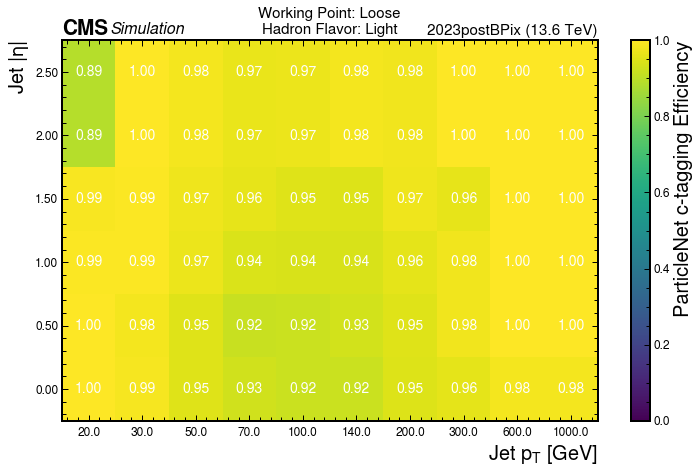

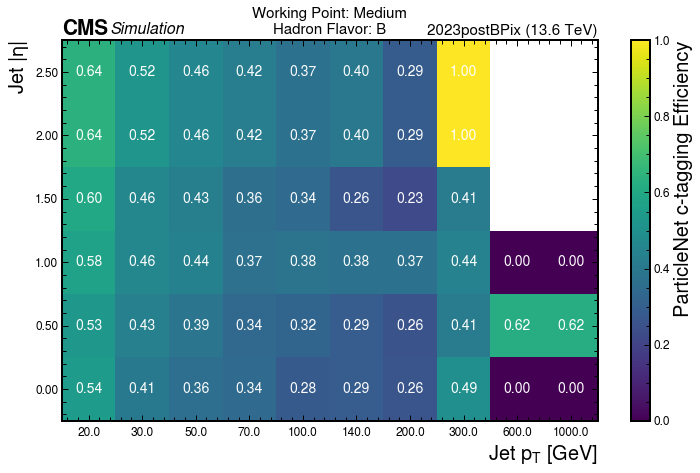

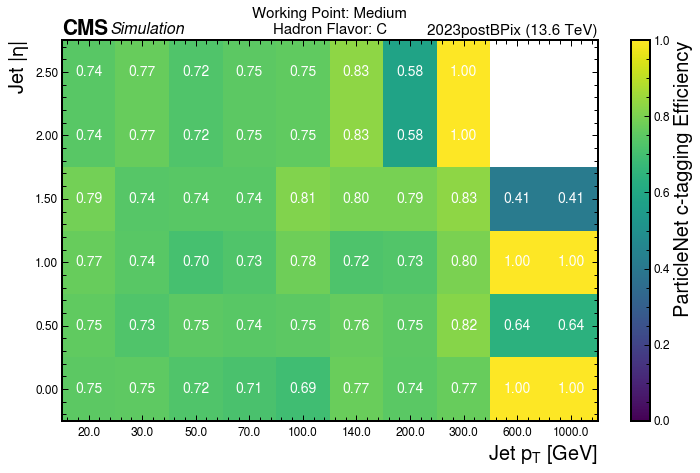

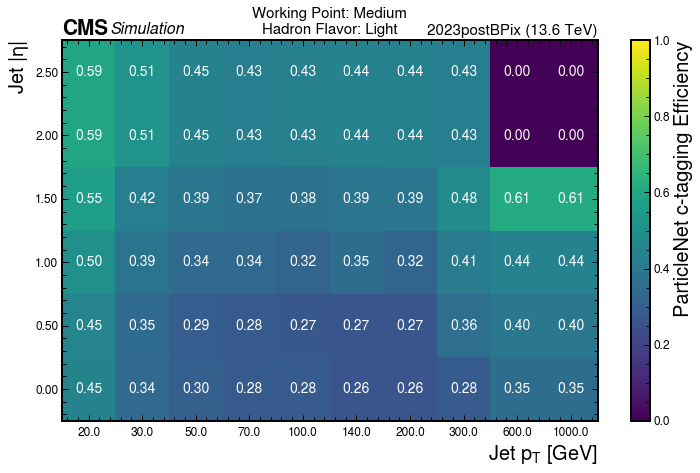

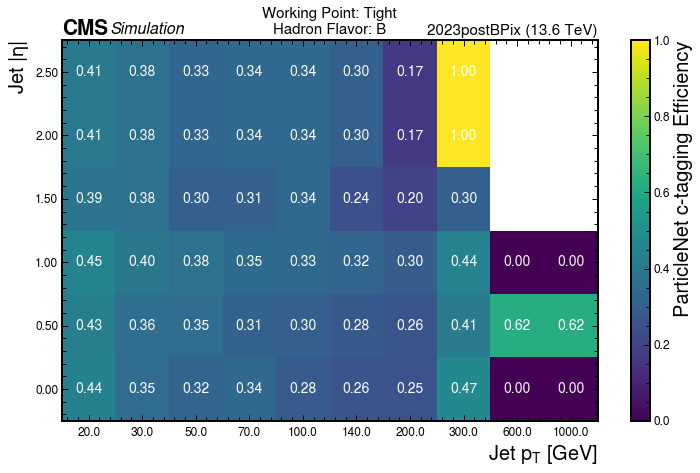

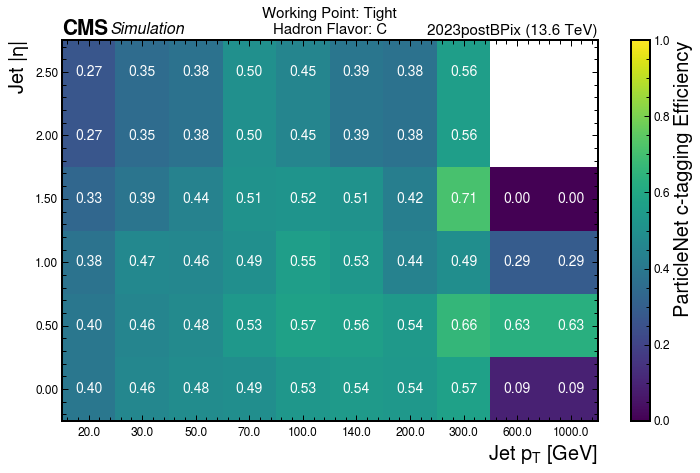

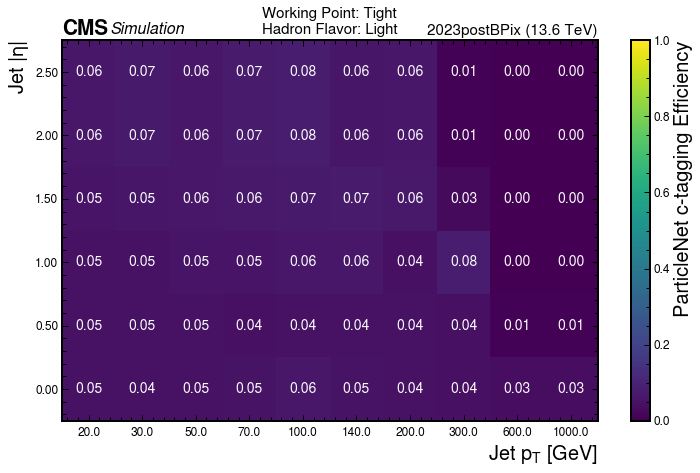

In [4]:
for year in ["2022preEE", "2022postEE", "2023preBPix", "2023postBPix"]:

    processed_histograms = util.load(f"../outputs/ctag_pnet_eff/{year}/{year}_processed_histograms.coffea")
    tag_efficiency_hist = processor.accumulate(processed_histograms.values())
    
    for wp in ["loose", "medium", "tight"]:
        
        # compute efficiency histogram
        numerator = tag_efficiency_hist[f"eff_{wp}_wp"][{f"jet_pass_{wp}_wp": True}]
        denominator = tag_efficiency_hist[f"eff_{wp}_wp"][{f"jet_pass_{wp}_wp": sum}]
        efficiency = numerator / denominator
        # create look-up table from the efficiency map
        efflookup = dense_lookup(efficiency.values(), [ax.edges for ax in efficiency.axes]) 
        # notice that hadron flavours (0, 4, 5) turn into (0, 1, 2). Let's modify them to their original values
        efflookup._axes[-1] = np.array([0., 4., 5., 6.])
        # get (pT,|eta|) grid
        pts = efficiency.axes["jet_pt"].edges
        etas = efficiency.axes["jet_abseta"].edges
        pt, eta = np.meshgrid(pts, etas)
        # plot efficiencies for all hadron flavors
        flavor_tags = {0: "Light", 4: "C", 5: "B"}
        for i, flav in enumerate([5, 4, 0]):
            fig, ax = plt.subplots(figsize=(12, 7))
            eff_map = efflookup(pt, eta, flav)
            
            heatmap = ax.pcolormesh(eff_map, vmin=0, vmax=1)
            for y in range(eff_map.shape[0]):
                for x in range(eff_map.shape[1]):
                    plt.text(x + 0.5, y + 0.5, '%.2f' % eff_map[y, x],
                             horizontalalignment='center',
                             verticalalignment='center',
                             color="w",
                             fontsize=14,
                             )
            cbar = fig.colorbar(heatmap)
            cbar.set_label('ParticleNet c-tagging Efficiency')
            
            ax.set_xlabel('Jet $p_T$ [GeV]')
            ax.set_ylabel('Jet |$\eta$|')
            ax.set_title(f"Working Point: {wp.title()}\nHadron Flavor: {flavor_tags[flav]}", size=15)
            
            ax.set_xticks(np.arange(len(pts))+0.5)  # Centering ticks between heatmap cells
            ax.set_xticklabels(pts)
            ax.set_yticks(np.arange(len(etas))+0.5)  # Centering ticks between heatmap cells
            ax.set_yticklabels([f"{eta_val:.2f}" for eta_val in etas])
            
            hep.cms.lumitext(f"{year} (13.6 TeV)", ax=ax)
            hep.cms.text("Simulation", loc=0, ax=ax)
            plt.show()
            plt.close()
        
        # save look-up table
        output_path = f"../analysis/data/ctag_pnet_eff_{wp}_{year}.coffea"
        util.save(efflookup, output_path)